
## 1. Introdução ao Problema
A observação da Terra através de imagens de satélite é crucial para a gestão ambiental, o planeamento urbano e a monitorização de alterações climáticas. O problema central deste trabalho consiste na **Classificação de Imagens de Satélite** para identificar automaticamente o tipo de uso e cobertura do solo.

## 2. Descrição do Conjunto de Dados
O conjunto de dados escolhido foi o **EuroSAT**, baseado em imagens de satélite do Sentinel-2.
* **Volume de Dados:** $27.000$ imagens perfeitamente rotuladas.
* **Dimensões:** Imagens RGB (3 canais) com a resolução de $64 \times 64$ píxeis.
* **Classes (10):** Culturas anuais, Floresta, Vegetação Herbácea, Autoestrada, Área Industrial, Pastagem, Culturas Permanentes, Área Residencial, Rios e Mares/Lagos.

## 3. Fundamentação Teórica da Arquitetura Utilizada
Para a resolução de problemas de Visão Computacional, as Redes Neuronais Convolucionais (CNN) representam o estado da arte. A arquitetura baseia-se nos seguintes pilares fundamentais:

* **Camadas Convolucionais:** Aplicam matrizes matemáticas (filtros ou kernels) que deslizam pela imagem para extrair características hierárquicas (desde arestas simples até texturas complexas).

* **Camadas de *Pooling* (Subamostragem):** O Max Pooling reduz a dimensionalidade espacial dos mapas de características, tornando a rede invariante a pequenas translações e poupando processamento computacional.

* **Regularização (*Dropout*):** Desativa aleatoriamente uma percentagem de neurônios durante o treino. Na teoria do Deep Learning, isto impede que os neurônios memorizem os dados de forma co-dependente, prevenindo o colapso por memorização (Overfitting).

* **Camadas Densas (Fully Connected):** Processam o vetor final achatado para tomar a decisão matemática e atribuir as probabilidades às 10 classes.

In [1]:
# Instalação das dependências necessárias (Descomente se for rodar no Colab)
# !pip install torch torchvision matplotlib


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random
import os


SEED = 67

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)


# Configurar dispositivo para GPU se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treino a ser executado no dispositivo: {device}")


# Converte a imagem para Tensor (valores de 0.0 a 1.0) e normaliza os 3 canais de cor (RGB).
# O uso do 0.5 centraliza os dados no zero (escala -1.0 a 1.0) para estabilizar os gradientes matemáticos.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=transform)

tamanho_treino = int(0.8 * len(dataset))
tamanho_teste = len(dataset) - tamanho_treino
gerador = torch.Generator().manual_seed(SEED)
train_set, test_set = random_split(dataset, [tamanho_treino, tamanho_teste], generator=gerador)

print(f"Total de Imagens: {len(dataset)} | Treino: {tamanho_treino} | Teste: {tamanho_teste}")

classes = ('AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
           'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake')

Treino a ser executado no dispositivo: cuda
Total de Imagens: 27000 | Treino: 21600 | Teste: 5400


---
## 4. Descrição das Arquiteturas Implementadas
Foram projetadas duas arquiteturas de CNN para comparação:

**Modelo A (CNN Base):**
Concebida propositadamente como uma rede "rasa". Contém apenas 2 camadas convolucionais (de 16 e 32 filtros), seguidas por agrupamento espacial (Max Pooling). Termina com uma rede densa. Não possui técnicas de regularização, o que a torna altamente suscetível à memorização bruta dos píxeis.

**Modelo B (CNN Melhorada):**
Uma rede mais profunda focada na extração de características semânticas de alto nível. Possui 3 camadas convolucionais progressivas (32 -> 64 -> 128 filtros), permitindo captar texturas complexas (como a densidade de uma floresta). Mais importante, introduz-se a técnica de Dropout (50%) na camada densa, que atua como um penalizador matemático para garantir a integridade da generalização.

In [3]:
# --- MODELO A: CNN BASE ---
class CNN_Base(nn.Module):
    def __init__(self):
        super(CNN_Base, self).__init__()

        #Começa com 3 canais (RGB), aplica filtros e gera 16 canais na saída, o tamanho do filtro é 3x3
        #O padding cria uma borda falsa de 1 pixel ao redor da imagem para evitar que a imagem encolha após os filtros
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Subamostragem: Reduz a resolução da imagem para metade (ex: 64x64 -> 32x32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        #Cria uma camada onde cada neurônio está conectado a todos os neurônios da camada seguinte
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    # Passa pela convolução -> ativação ReLU -> redução de tamanho MaxPool
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        # Achata o volume 3D gerado pelas convoluções num vetor linear 1D
        x = torch.flatten(x, 1)

        # Camadas densas para a decisão de classificação final
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# --- MODELO B: CNN MELHORADA (Com Dropout) ---
class CNN_Melhorada(nn.Module):
    def __init__(self):
        super(CNN_Melhorada, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

---
## 5. Configuração Utilizada para Treinamento (Experimentos)

Para evidenciar os fenômenos matemáticos da aprendizagem das redes, aplicamos um Teste de Stress de 20 épocas em ambos os modelos, alterando a filosofia paramétrica entre eles:
1. **CNN Base (Convergência Agressiva):** Utiliza um passo largo na Taxa de Aprendizagem (0.001) acoplado a um tamanho de lote mais ruidoso (Batch Size = 32). O objetivo é forçar a rede a convergir extremamente depressa para demonstrar o limite da arquitetura rasa.
2. **CNN Melhorada (Convergência Generalista):** Focada na estabilidade. Utiliza um passo 10 vezes menor (0.0001) e avalia o gradiente em lotes maiores (64 imagens por vez). Devido ao peso do Dropout (onde 50% da rede é desligada a cada passo), esta configuração dita uma aprendizagem muito mais cautelosa e demorada, exigindo as 20 épocas para amadurecer a extração das 10 classes de satélite.

In [4]:
# Função universal de treino e avaliação
def treinar_modelo(modelo, train_loader, test_loader, epochs, lr):
    torch.manual_seed(SEED)
    
    modelo.to(device)

    # Função de perda ideal para múltiplas classes (mede a distância do erro)
    criterion = nn.CrossEntropyLoss() 

    # Otimizador Adam: usa o Learning Rate (lr) para atualizar os pesos da rede
    optimizer = optim.Adam(modelo.parameters(), lr=lr)
    

    # Armazenam o histórico de cada época para permitir a plotagem dos gráficos de Overfitting no final.
    historico_loss_treino = []
    historico_loss_teste = []
    historico_acc_treino = []
    historico_acc_teste = []
    
    for epoch in range(epochs):
        # --- Treino ---
        modelo.train() # Ativa o Dropout
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        # O DataLoader entrega as imagens em pequenos lotes (ex: 64 por vez)
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()               # Zera a memória matemática (gradientes antigos)
            outputs = modelo(inputs)            # Forward Pass: Rede tenta adivinhar a imagem
            loss = criterion(outputs, labels)   # Calcula o Erro (Loss) da adivinhação
            loss.backward()                     # Backpropagation: Descobre quais neurônios erraram
            optimizer.step()                    # Atualiza os pesos para melhorar na próxima
            
            running_loss += loss.item()

            # Pega o índice da classe que recebeu a maior pontuação da rede
            _, predicted = torch.max(outputs.data, 1)

            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        acc_treino = 100 * correct_train / total_train
        historico_loss_treino.append(running_loss / len(train_loader))
        historico_acc_treino.append(acc_treino)
        
        # --- Avaliação (Validação) ---
        modelo.eval()       # Desliga o Dropout
        running_loss_teste = 0.0
        correct_test = 0
        total_test = 0

        
        with torch.no_grad():       # Suspende os cálculos de gradientes
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = modelo(inputs)
                
                # Calcula o erro matemático nas imagens de teste
                loss_test = criterion(outputs, labels)
                running_loss_teste += loss_test.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
                
        acc_teste = 100 * correct_test / total_test
        historico_loss_teste.append(running_loss_teste / len(test_loader))
        historico_acc_teste.append(acc_teste)
        
        print(f'Época [{epoch+1}/{epochs}] | Loss Treino: {historico_loss_treino[-1]:.4f} | Loss Teste: {historico_loss_teste[-1]:.4f} | Acc Treino: {acc_treino:.2f}% | Acc Teste: {acc_teste:.2f}%')
        
    return historico_loss_treino, historico_loss_teste, historico_acc_treino, historico_acc_teste

In [5]:
# --- EXPERIMENTO 1: CNN BASE ---
print("==============================================")
print("A TREINAR EXPERIMENTO 1 (CNN BASE)")
print("LR: 0.001 | Batch: 32 | Sem Dropout | 2 Camadas")
print("==============================================")

#O tamanho do lote diz à rede quantas imagens ela deve olhar antes de ajustar o seu aprendizado
batch_size_base = 32

# O shuffle=True no treino é vital para a rede não decorar a ordem das imagens.
train_loader_base = DataLoader(train_set, batch_size=batch_size_base, shuffle=True)
test_loader_base = DataLoader(test_set, batch_size=batch_size_base, shuffle=False)

modelo_base = CNN_Base()
loss_treino_base, loss_teste_base, acc_treino_base, acc_teste_base = treinar_modelo(
    modelo_base, train_loader_base, test_loader_base, epochs=20, lr=0.001
)

A TREINAR EXPERIMENTO 1 (CNN BASE)
LR: 0.001 | Batch: 32 | Sem Dropout | 2 Camadas
Época [1/20] | Loss Treino: 1.0201 | Loss Teste: 0.7316 | Acc Treino: 62.72% | Acc Teste: 72.96%
Época [2/20] | Loss Treino: 0.6440 | Loss Teste: 0.6155 | Acc Treino: 76.80% | Acc Teste: 77.15%
Época [3/20] | Loss Treino: 0.5357 | Loss Teste: 0.6411 | Acc Treino: 80.80% | Acc Teste: 77.31%
Época [4/20] | Loss Treino: 0.4428 | Loss Teste: 0.5504 | Acc Treino: 84.07% | Acc Teste: 81.15%
Época [5/20] | Loss Treino: 0.3749 | Loss Teste: 0.4824 | Acc Treino: 86.81% | Acc Teste: 83.26%
Época [6/20] | Loss Treino: 0.3209 | Loss Teste: 0.5246 | Acc Treino: 88.67% | Acc Teste: 82.76%
Época [7/20] | Loss Treino: 0.2558 | Loss Teste: 0.5094 | Acc Treino: 91.28% | Acc Teste: 84.09%
Época [8/20] | Loss Treino: 0.2124 | Loss Teste: 0.5617 | Acc Treino: 92.62% | Acc Teste: 82.67%
Época [9/20] | Loss Treino: 0.1719 | Loss Teste: 0.5253 | Acc Treino: 94.19% | Acc Teste: 84.17%
Época [10/20] | Loss Treino: 0.1451 | Loss T

In [6]:
# --- EXPERIMENTO 2: CNN MELHORADA ---
print("\n==============================================")
print("A TREINAR EXPERIMENTO 2 (CNN MELHORADA)")
print("LR: 0.0001 | Batch: 64 | Com Dropout | 3 Camadas")
print("==============================================")

batch_size_melhorada = 64
train_loader_melhorada = DataLoader(train_set, batch_size=batch_size_melhorada, shuffle=True)
test_loader_melhorada = DataLoader(test_set, batch_size=batch_size_melhorada, shuffle=False)

modelo_melhorada = CNN_Melhorada()
loss_treino_melhorada, loss_teste_melhorada, acc_treino_melhorada, acc_teste_melhorada = treinar_modelo(
    modelo_melhorada, train_loader_melhorada, test_loader_melhorada, epochs=20, lr=0.0001
)


A TREINAR EXPERIMENTO 2 (CNN MELHORADA)
LR: 0.0001 | Batch: 64 | Com Dropout | 3 Camadas
Época [1/20] | Loss Treino: 1.5979 | Loss Teste: 1.1624 | Acc Treino: 40.81% | Acc Teste: 60.67%
Época [2/20] | Loss Treino: 1.1449 | Loss Teste: 0.9870 | Acc Treino: 58.99% | Acc Teste: 64.04%
Época [3/20] | Loss Treino: 0.9913 | Loss Teste: 0.8327 | Acc Treino: 64.64% | Acc Teste: 70.19%
Época [4/20] | Loss Treino: 0.9019 | Loss Teste: 0.7669 | Acc Treino: 68.06% | Acc Teste: 72.65%
Época [5/20] | Loss Treino: 0.8270 | Loss Teste: 0.7151 | Acc Treino: 70.25% | Acc Teste: 74.91%
Época [6/20] | Loss Treino: 0.7804 | Loss Teste: 0.6675 | Acc Treino: 72.22% | Acc Teste: 75.57%
Época [7/20] | Loss Treino: 0.7493 | Loss Teste: 0.6690 | Acc Treino: 73.42% | Acc Teste: 75.87%
Época [8/20] | Loss Treino: 0.7143 | Loss Teste: 0.6097 | Acc Treino: 74.56% | Acc Teste: 77.69%
Época [9/20] | Loss Treino: 0.6837 | Loss Teste: 0.6033 | Acc Treino: 75.73% | Acc Teste: 78.15%
Época [10/20] | Loss Treino: 0.6699 |

---
## 6. Resultados Obtidos (Análise de Acurácia e Erro)


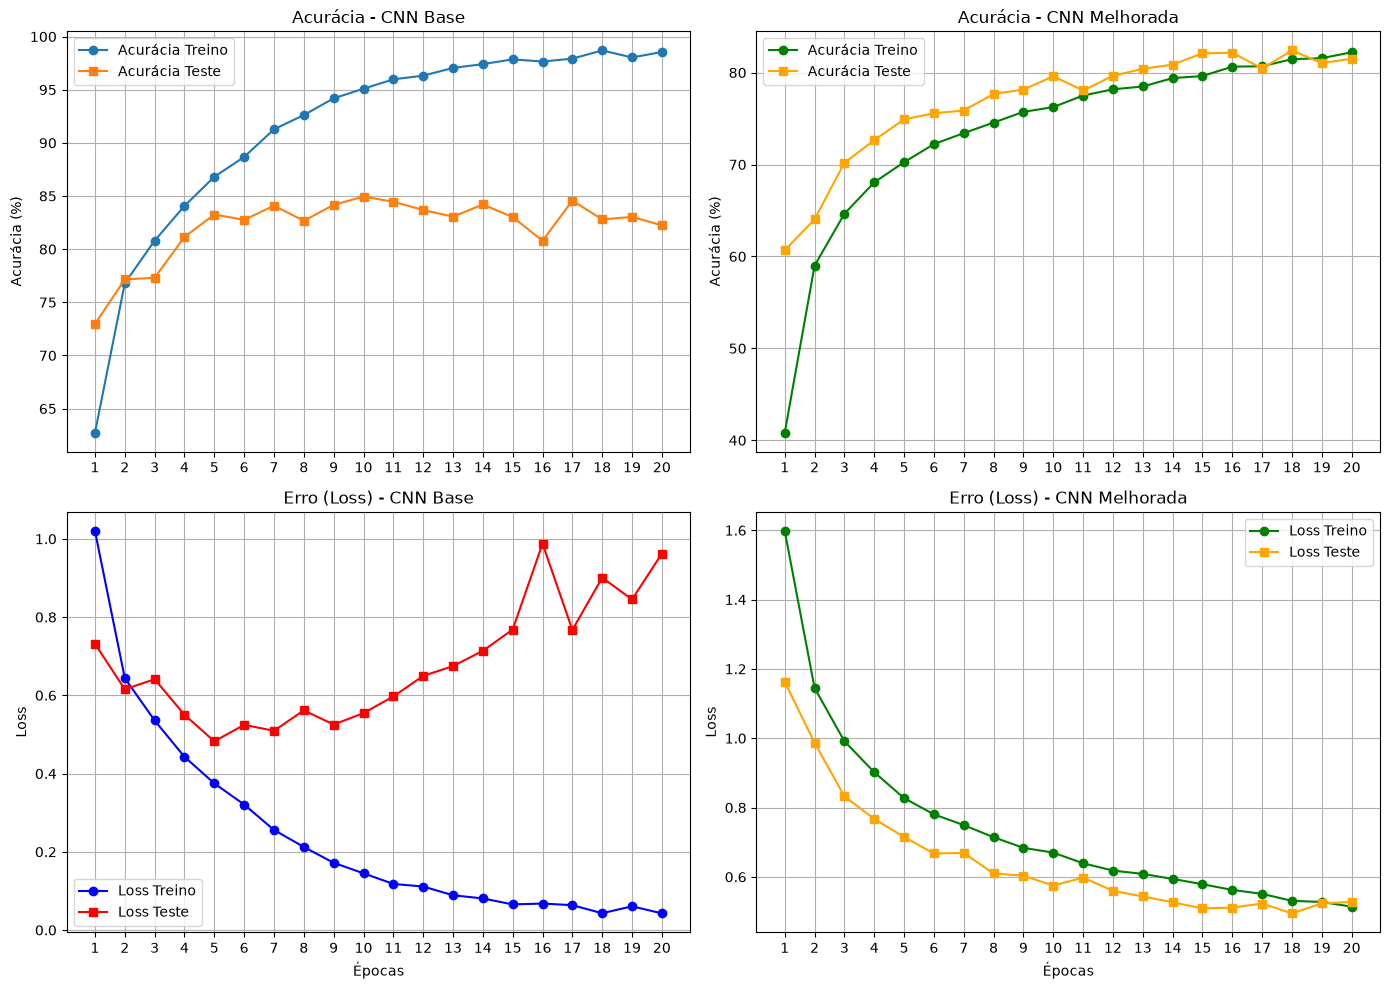

In [7]:
# Eixos X dinâmicos
epocas_base = range(1, len(acc_treino_base) + 1)
epocas_melhorada = range(1, len(acc_treino_melhorada) + 1)

plt.figure(figsize=(14, 10))

# --- GRÁFICOS DE ACURÁCIA ---
plt.subplot(2, 2, 1)
plt.plot(epocas_base, acc_treino_base, label='Acurácia Treino', marker='o')
plt.plot(epocas_base, acc_teste_base, label='Acurácia Teste', marker='s')
plt.title('Acurácia - CNN Base')
plt.ylabel('Acurácia (%)')
plt.xticks(epocas_base) 
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(epocas_melhorada, acc_treino_melhorada, label='Acurácia Treino', marker='o', color='green')
plt.plot(epocas_melhorada, acc_teste_melhorada, label='Acurácia Teste', marker='s', color='orange')
plt.title('Acurácia - CNN Melhorada')
plt.ylabel('Acurácia (%)')
if len(epocas_melhorada) <= 20:
    plt.xticks(epocas_melhorada)
plt.legend()
plt.grid(True)

# --- GRÁFICOS DE ERRO MATEMÁTICO (LOSS) ---
plt.subplot(2, 2, 3)
plt.plot(epocas_base, loss_treino_base, label='Loss Treino', marker='o', color='blue')
plt.plot(epocas_base, loss_teste_base, label='Loss Teste', marker='s', color='red') # Loss teste em vermelho
plt.title('Erro (Loss) - CNN Base')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.xticks(epocas_base)
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(epocas_melhorada, loss_treino_melhorada, label='Loss Treino', marker='o', color='green')
plt.plot(epocas_melhorada, loss_teste_melhorada, label='Loss Teste', marker='s', color='orange')
plt.title('Erro (Loss) - CNN Melhorada')
plt.xlabel('Épocas')
plt.ylabel('Loss')
if len(epocas_melhorada) <= 20:
    plt.xticks(epocas_melhorada)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## 7. Comparação entre os Experimentos Realizados

A análise crítica dos gráficos submetidos ao teste estendido de 20 épocas revela, com extrema clareza, o fenômeno clássico da memorização de dados (Overfitting):

1. **O Colapso da CNN Base (Gráfico de Erro):**
Devido à sua topologia rasa e ausência de regularização, a CNN Base esmagou o Erro (Loss) no Treino para um valor quase nulo (0.04). No entanto, ao analisar o Erro no Teste (linha vermelha), detectamos uma violenta curva em "U". O erro do modelo no mundo real atingiu o seu mínimo na época 5 (0.48) e depois explodiu para cima, terminando a época 20 em 0.96 (o dobro do erro). A rede deixou de aprender e passou a dedicar todo o seu processamento a decorar o ruído das fotografias de treino. Isso gerou um abismo de mais de 16% entre a acurácia declarada no treino (98.5%) e a capacidade real no teste (82.2%).

2. **A Integridade da CNN Melhorada:**
A adição de 128 filtros e do Dropout (50%) limitou severamente a capacidade da rede de fazer "batota" decorando dados. Como resultado, as curvas de Treino e Teste da CNN Melhorada desceram perfeitamente coladas do início ao fim (terminando ambas em torno de um Loss de 0.51 a 0.52). Com 82% de acurácia honesta em ambas as frentes, ela provou que, embora aprenda mais devagar, constrói uma inteligência visual incrivelmente robusta e imune à memorização.

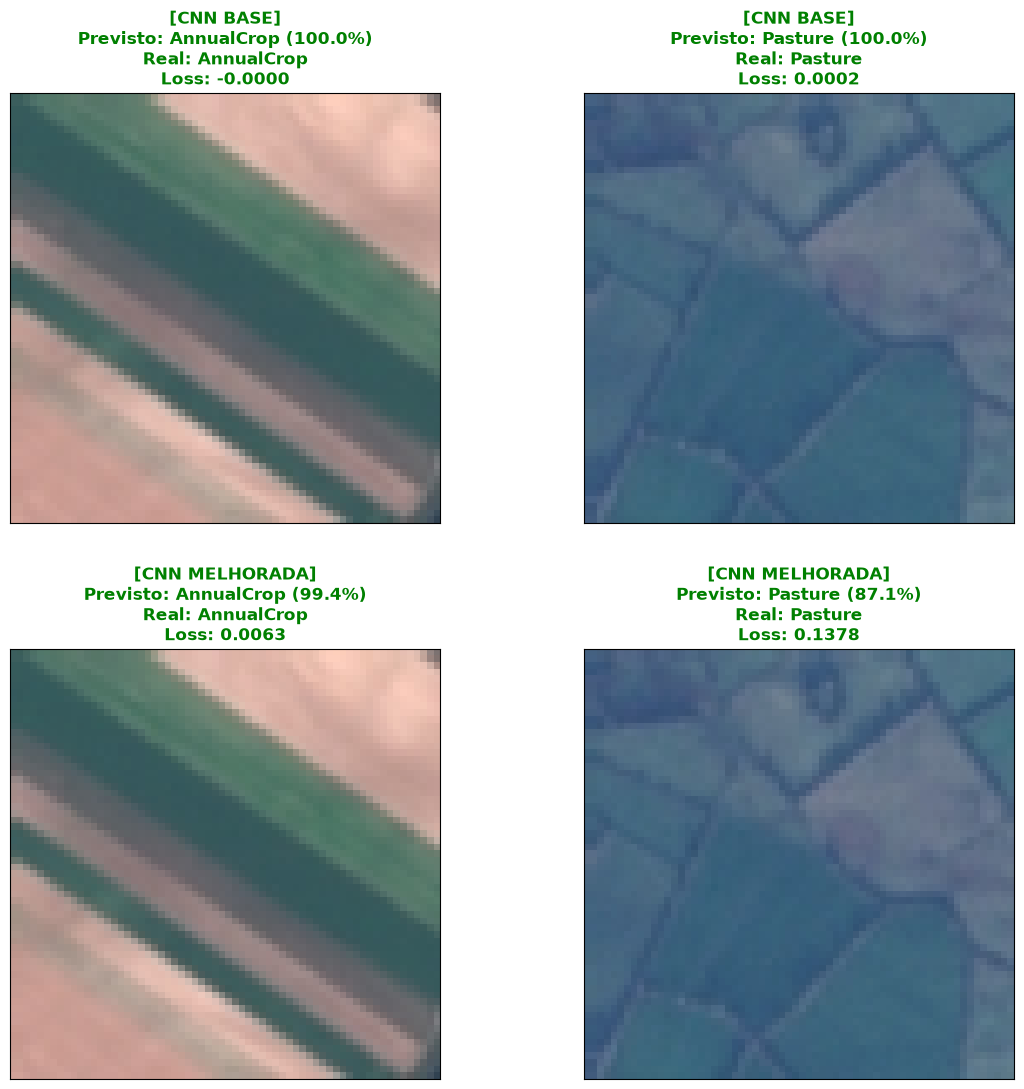

In [8]:
# --- VISUALIZAÇÃO COMPARATIVA (CNN BASE vs CNN MELHORADA) ---
torch.manual_seed(SEED)
dataiter = iter(test_loader_melhorada)
images, labels = next(dataiter)

images_gpu = images[:2].to(device)
labels_subset = labels[:2].to(device)


criterion_individual = nn.CrossEntropyLoss(reduction='none')

modelo_base.eval()
with torch.no_grad():
    outputs_base = modelo_base(images_gpu)
    probabilidades_base = torch.softmax(outputs_base, dim=1)
    certeza_base, predicted_base = torch.max(probabilidades_base, 1)
    loss_individual_base = criterion_individual(outputs_base, labels_subset)

modelo_melhorada.eval()
with torch.no_grad():
    outputs_melhorada = modelo_melhorada(images_gpu)
    probabilidades_melhorada = torch.softmax(outputs_melhorada, dim=1)
    certeza_melhorada, predicted_melhorada = torch.max(probabilidades_melhorada, 1)
    loss_individual_melhorada = criterion_individual(outputs_melhorada, labels_subset)

def imshow(img):
    img = img / 2 + 0.5  
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

fig = plt.figure(figsize=(12, 11))

for i in range(2):
    ax = fig.add_subplot(2, 2, i+1, xticks=[], yticks=[])
    imshow(images[i].cpu())
    cor = 'green' if predicted_base[i] == labels_subset[i] else 'red'
    confianca_pct = certeza_base[i].item() * 100
    loss_val = loss_individual_base[i].item()
    titulo = f"[CNN BASE]\nPrevisto: {classes[predicted_base[i]]} ({confianca_pct:.1f}%)\nReal: {classes[labels_subset[i]]}\nLoss: {loss_val:.4f}"
    ax.set_title(titulo, color=cor, fontweight='bold')

for i in range(2):
    ax = fig.add_subplot(2, 2, i+3, xticks=[], yticks=[])
    imshow(images[i].cpu())
    cor = 'green' if predicted_melhorada[i] == labels_subset[i] else 'red'
    confianca_pct = certeza_melhorada[i].item() * 100
    loss_val = loss_individual_melhorada[i].item()
    titulo = f"[CNN MELHORADA]\nPrevisto: {classes[predicted_melhorada[i]]} ({confianca_pct:.1f}%)\nReal: {classes[labels_subset[i]]}\nLoss: {loss_val:.4f}"
    ax.set_title(titulo, color=cor, fontweight='bold')

plt.tight_layout(h_pad=3.0)
plt.show()

## 8. Conclusões

A visualização empírica das imagens corrobora de forma definitiva as consequências do Overfitting analisado nos gráficos anteriores. A CNN Base, por ter os seus pesos desregulados e superajustados pela memorização, sofre de excesso de confiança, cravando exatos 100.0% de certeza cegamente na maioria das imagens de teste.

Em total contraste, a CNN Melhorada, penalizada iterativamente pelo Dropout, aprendeu a reconhecer as nuances das texturas da superfície terrestre de forma honesta. Ela entrega percentagens bem calibradas e ponderadas (como 87% em terrenos confusos ou 99% baseados em características legítimas), justificando a sobreposição perfeita das suas curvas de treino e teste.

Concluímos que a parametrização em Redes Neuronais exige o sacrifício da velocidade de aprendizagem bruta em prol da generalização. O uso de arquiteturas ligeiramente mais densas aliadas ao amortecimento adequado da Taxa de Aprendizagem e, obrigatoriamente, a técnicas de regularização (como o Dropout) provaram ser o caminho definitivo para desenvolver inteligências de Visão Computacional prontas e confiáveis para cenários do mundo real.

## 9. Referências Bibliográficas
* **PyTorch Documentation:** Documentação oficial para construção de redes neuronais e funções de perda. Disponível em: https://pytorch.org/docs/
* **EuroSAT Dataset:** Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification*. IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing.
* **EuroSAT Dataset (Torchvision):** Documentação e implementação oficial do conjunto de dados na biblioteca PyTorch. Disponível em: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.EuroSAT.html